# Mathematical exercises

**Exercise 1** (3 points): Problem 9.4 in the PRML textbook.

**Exercise 2**: (3 points): Problem 9.14 in the PRML textbook.

# Coding exercises

In the exercises below, we will implement the expectation maximization (EM) algorithm, applying it to a mixture of Gaussians model to describe clustering in data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Mixture model for synthetic data

To begin, we'll generate some synthetic data from a mixture of Gaussians model. Each data point is generated from one of two multimodal Gaussian distributions, but the points aren't given any labels.

Text(0, 0.5, 'x2')

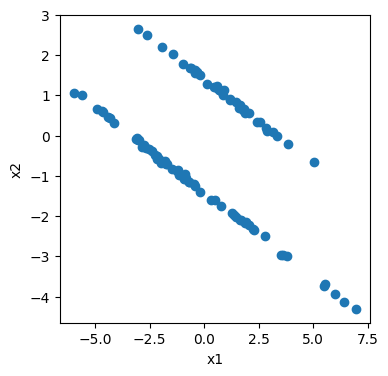

In [2]:
# Make some fake data.

d = 2  # dimensionality of data
n = 100  # total number of data points

# Generate means (we'll use underscores to denote the true parameters, which we'll try to infer below):
mu1_ = np.ones(d)
mu2_ = -np.ones(d)

# Generate covariance matrices as linear combinations of outer products of basis vectors:
vecs = np.random.randn(d,d)
Sigma1_ = np.sum([(0.5+np.random.rand())*np.outer(vecs[i], vecs[i]) for i in range(d)], axis=0)
Sigma2_ = np.sum([(0.5+np.random.rand())*np.outer(vecs[i], vecs[i]) for i in range(d)], axis=0)

# The mixture probabilities:
pi1_, pi2_ = 0.4, 0.6 

# For each data point, choose a cluster that it belongs to and generate its location:
x = np.zeros((0,d))
labels = []  # we won't use cluster labels for fitting, but we'll use it to check the model below
for ii in range(n):
    if np.random.rand() < pi1_:
        x = np.vstack((x, np.random.multivariate_normal(mu1_, Sigma1_)))
        labels.append(0)
    else:
        x = np.vstack((x, np.random.multivariate_normal(mu2_, Sigma2_)))
        labels.append(1)

# Plot the data:
plt.figure(figsize=(4,4))
plt.plot(x[:,0], x[:,1], 'o')
plt.xlabel('x1')
plt.ylabel('x2')

**Exercise 1** (5 points): Implement the EM algorithm to find the maximum likelihood solution for a mixture of Gaussians model with $K=2$ applied to the data above. Report the inferred values of the means and mixture probabilities. Plot the value of the log likelihood at each step in the iteration and show that it converges. Finally, plot the data on top of a contour plot illustrating the expected distribution under the fitted model. The algorithm should be implemented from scratch, with only basic Numpy functions being used.

In [3]:
## Solution ##

K = 2
max_iter = 200
tol = 1e-6

# initialize params randomly
idx = np.random.choice(n, K, replace=False) # pick two random data points as initial means
mu    = x[idx].copy()                              # (K, d)
Sigma = np.array([np.eye(d) for _ in range(K)])    # (K, d, d)
pi    = np.ones(K) / K                             # (K,)

log_likelihoods = []

# ── EM loop ─────────────────────────────────────────────────────────────────
for iteration in range(max_iter):

    # E-step: compute responsibilities
    weighted = np.zeros((K, n))
    for k in range(K):
        diff      = x - mu[k]                                        # (n, d)
        Sigma_inv = np.linalg.inv(Sigma[k])                          # (d, d)
        exponent  = -0.5 * (diff @ Sigma_inv * diff).sum(axis=1)     # (n,)
        norm      = np.sqrt((2 * np.pi) ** d * np.linalg.det(Sigma[k]))
        weighted[k] = pi[k] * np.exp(exponent) / norm

    total = weighted.sum(axis=0)                   # (n,)
    r     = weighted / total                       # (K, n)
    log_likelihood = np.sum(np.log(total))
    log_likelihoods.append(log_likelihood)

    # M-step: update parameters
    for k in range(K):
        Nk      = r[k].sum()
        pi[k]   = Nk / n
        mu[k]   = (r[k] @ x) / Nk
        diff    = x - mu[k]
        Sigma[k] = (r[k] * diff.T) @ diff / Nk

    # Check convergence
    if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
        print(f"Converged at iteration {iteration}")
        break

print("Fitted means:\n", mu)
print("Fitted mixing coefficients:", pi)


Converged at iteration 20
Fitted means:
 [[-0.4582431  -1.21443099]
 [ 0.92038141  1.02414735]]
Fitted mixing coefficients: [0.6 0.4]


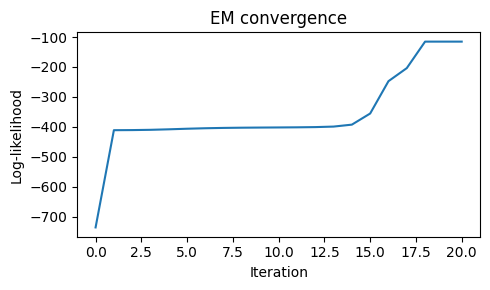

/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_85544/1552613331.py:23: RuntimeWarning: divide by zero encountered in matmul
  exp_g     = -0.5 * (diff_g @ Sigma_inv * diff_g).sum(axis=1)
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_85544/1552613331.py:23: RuntimeWarning: overflow encountered in matmul
  exp_g     = -0.5 * (diff_g @ Sigma_inv * diff_g).sum(axis=1)
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_85544/1552613331.py:23: RuntimeWarning: invalid value encountered in matmul
  exp_g     = -0.5 * (diff_g @ Sigma_inv * diff_g).sum(axis=1)


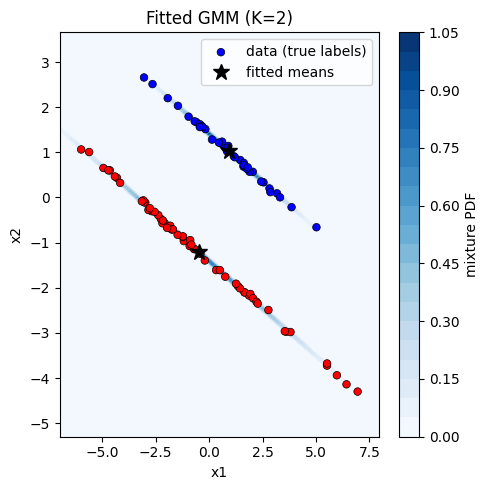

In [4]:
# ── Plot 1: log-likelihood convergence ─────────────────────────────────────
plt.figure(figsize=(5, 3))
plt.plot(log_likelihoods)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("EM convergence")
plt.tight_layout()
plt.show()

# ── Plot 2: data + contour of fitted mixture ────────────────────────────────
# Build a grid covering the data range
margin = 1.0
x1 = np.linspace(x[:, 0].min() - margin, x[:, 0].max() + margin, 200)
x2 = np.linspace(x[:, 1].min() - margin, x[:, 1].max() + margin, 200)
X1, X2 = np.meshgrid(x1, x2)
grid = np.column_stack([X1.ravel(), X2.ravel()])   # (200*200, 2)

# Evaluate mixture PDF on the grid
pdf_grid = np.zeros(grid.shape[0])
for k in range(K):
    diff_g    = grid - mu[k]                                           # (M, d)
    Sigma_inv = np.linalg.inv(Sigma[k])
    exp_g     = -0.5 * (diff_g @ Sigma_inv * diff_g).sum(axis=1)
    norm_g    = np.sqrt((2 * np.pi) ** d * np.linalg.det(Sigma[k]))
    pdf_grid += pi[k] * np.exp(exp_g) / norm_g

Z = pdf_grid.reshape(X1.shape)

plt.figure(figsize=(5, 5))
plt.contourf(X1, X2, Z, levels=20, cmap='Blues')
plt.colorbar(label='mixture PDF')
plt.scatter(x[:, 0], x[:, 1], c=np.array(labels), cmap='bwr',
            edgecolors='k', linewidths=0.5, s=30, label='data (true labels)')
plt.plot(mu[:, 0], mu[:, 1], 'k*', markersize=12, label='fitted means')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Fitted GMM (K=2)')
plt.legend()
plt.tight_layout()
plt.show()


**Exercise 2** (3 points): Now fit the same data the easy way using `GaussianMixture` from the `sklearn` library. Report the extimated mean vectors and mixture probabilities, as well as the fraction of cluster labels that are correctly predicted by the model by comparing the model's predicted cluster labels with the vector `labels` that we defined above.

In [5]:
from sklearn.mixture import GaussianMixture

## Solution ##

# Fit a K=2 GMM using sklearn
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(x)

# Report estimated means and mixing coefficients
print("Estimated means:\n", gmm.means_)
print("Estimated mixing coefficients:", gmm.weights_)

# Predict cluster labels for each data point
predicted_labels = gmm.predict(x)

# sklearn may assign cluster indices in a different order than our true labels.
# Try both orderings and pick the one with higher accuracy.
labels_arr = np.array(labels)
acc_direct = np.mean(predicted_labels == labels_arr)
acc_flipped = np.mean((1 - predicted_labels) == labels_arr)
accuracy = max(acc_direct, acc_flipped)

print(f"Fraction of labels correctly predicted: {accuracy:.3f}")


Estimated means:
 [[-1.23141606 -0.06993579]
 [ 2.00748366 -0.67893399]]
Estimated mixing coefficients: [0.59102693 0.40897307]
Fraction of labels correctly predicted: 0.800


## Mixture model for the Iris dataset

In class we explored the Iris dataset, which quantifies four characteristics of three different flower subspecies. Let's load that dataset again and look at some of its properties.

In [6]:
# Load the Iris dataset:
from sklearn.datasets import load_iris
data = load_iris()  # data is a dictionary containing lots of things

# List of the features and targets being measured:
print('Features: \n', data['feature_names'])
print('Targets: \n', data['target_names'])

# The input data (each row gives measurements of the features listed above):
X_iris = data['data']
n_samples, n_features = np.shape(data['data'])
print('n_samples, n_features: ', (n_samples, n_features))

# The target data (subspecies identity):
y_iris = data['target']

# Print the first few samples of x and y data:
print('X data: \n', X_iris[:3,:])
print('y data: \n', y_iris[:3])


Features: 
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Targets: 
 ['setosa' 'versicolor' 'virginica']
n_samples, n_features:  (150, 4)
X data: 
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
y data: 
 [0 0 0]


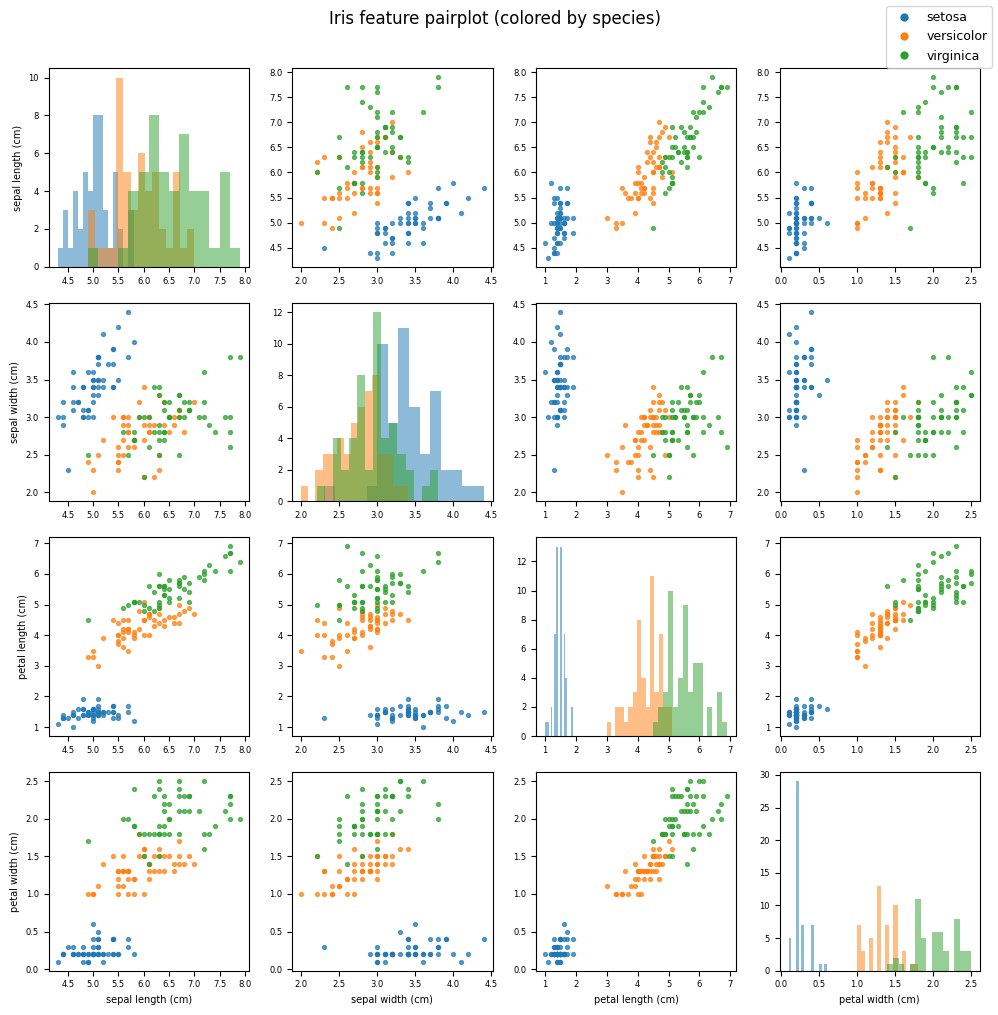

In [7]:
feature_names = data['feature_names']
target_names  = data['target_names']
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(n_features, n_features, figsize=(10, 10))

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]
        if i == j:
            # Diagonal: histogram of feature i per class
            for cls in range(3):
                ax.hist(X_iris[y_iris == cls, i], bins=15, alpha=0.5,
                        color=colors[cls], label=target_names[cls])
        else:
            # Off-diagonal: scatter of feature j (x) vs feature i (y)
            for cls in range(3):
                ax.scatter(X_iris[y_iris == cls, j], X_iris[y_iris == cls, i],
                           s=8, alpha=0.7, color=colors[cls])
        # Labels only on edges
        if i == n_features - 1:
            ax.set_xlabel(feature_names[j], fontsize=7)
        if j == 0:
            ax.set_ylabel(feature_names[i], fontsize=7)
        ax.tick_params(labelsize=6)

# Single legend
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=colors[c], markersize=7, label=target_names[c])
           for c in range(3)]
fig.legend(handles=handles, loc='upper right', fontsize=9)
plt.suptitle('Iris feature pairplot (colored by species)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


**Exercise 3** (4 points): Fit Gaussian mixture models to this data using the `GaussianMixture` class as above, now for several different values of $K$ (number of clusters). After reading the documentation of this class, plot, for each value of $K$, the model's log likelihood, as well as the Bayesian information criterion (BIC), which is the same as the negative log likelihood but also penalizes the number of parameters in the model (note that lower BIC scores are better; see the textbook or Wikipedia for more details). Give an explanation for why these curves look the way that they do. Based on the results, what number of clusters best describes the data? In general, how does the number of parameters in the mixture model depend on the number of features $M$ and the number of clusters $K$?

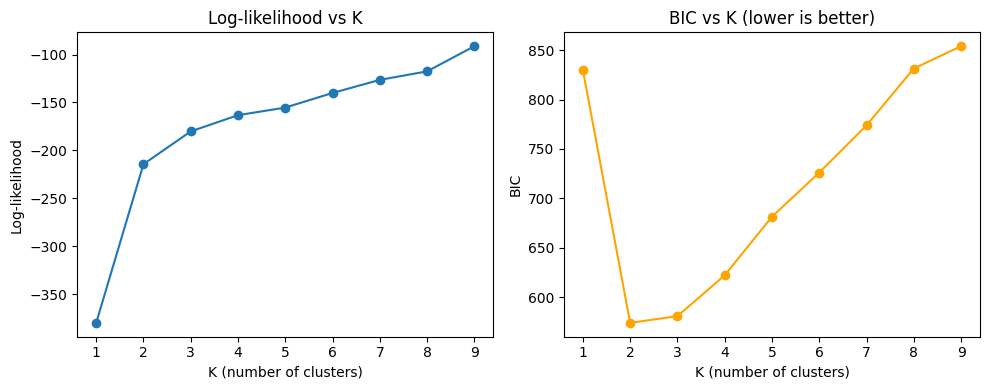

Best K by BIC: 2


In [8]:
## Solution ##

K_values = range(1, 10)
log_likelihoods_iris = []
bics = []

for k in K_values:
    gmm_k = GaussianMixture(n_components=k, random_state=42)
    gmm_k.fit(X_iris)
    log_likelihoods_iris.append(gmm_k.score(X_iris) * n_samples)  # total log-likelihood
    bics.append(gmm_k.bic(X_iris))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(K_values, log_likelihoods_iris, 'o-')
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Log-likelihood')
axes[0].set_title('Log-likelihood vs K')

axes[1].plot(K_values, bics, 'o-', color='orange')
axes[1].set_xlabel('K (number of clusters)')
axes[1].set_ylabel('BIC')
axes[1].set_title('BIC vs K (lower is better)')

plt.tight_layout()
plt.show()

best_k = K_values[np.argmin(bics)]
print(f"Best K by BIC: {best_k}")


According to the bayesian information criteria, k=2 is the best number of clusters that maximizes fit while minimizing parameters. This makes sense with the visualizations above because the versicolor and verginica are always overlapping in feature space but are well separated from the third flower, the setosa. In general the number of parameters grows quadratically in the mixture models because of the covariance matrix so adding more clusters increases the BIC penalty very quickly.

**Exercise 4** (5 points): Gaussian Mixture Models are frequently used for image segmentation—grouping pixels into regions based on color or intensity similarities. This is often a preprocessing step in image processing. Once an image is segmented into a small number of regions, it becomes much easier for a downstream algorithm to identify "foreground vs. background" or "sky vs. ground." This is a classic application of GMMs (specifically discussed in Bishop Section 9.2.2). It moves from low-dimensional tabular data (such as the Iris dataset or the toy dataset used above) to high-dimensional image data, but simplifies it by clustering pixel intensities.

As usual, responsible AI use is encouraged in this last exercise, e.g. using AI as a tutor explaining the theory and helping to implement parts you aren't sure about or debug implementations. Optionally, you may include a brief reflection on how you used AI and what you learned from the interaction.

1.  **Data:** Load a standard sample image (like the "racoon face" from `scipy.misc.face` or the "astronaut" from `skimage.data`). Downsample it slightly if you need faster processing.
2.  **Preprocessing:** Reshape the image array from `(height, width, 3)` into a flat list of pixels `(N, 3)` where $N$ is the total number of pixels and 3 represents the RGB channels.
3.  **Model Fitting:** Use `sklearn.mixture.GaussianMixture` to fit a GMM with $K=10$ components to the pixel data.
4.  **Reconstruction:** Replace every pixel in the original image with the mean color vector $\mathbf{\mu}_k$ of the cluster $k$ to which that pixel has the highest responsibility.
5.  **AI Collaboration:** Discuss with an AI assistant to explain why simply using $K$-Means (which assumes spherical clusters) might fail to capture valid color segments compared to a GMM (which allows ellipsoidal covariance). Summarize the answer in 2 sentences.

Image shape: (256, 256, 3)


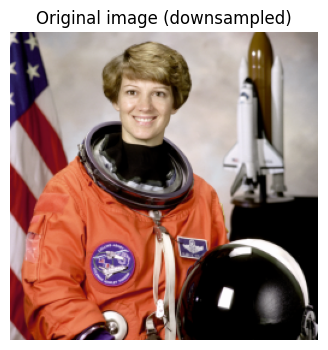

In [9]:
from skimage import data as skdata
from skimage.transform import rescale

# Step 1: Load image and downsample for faster processing
image = skdata.astronaut()           # (512, 512, 3) uint8 RGB
image = rescale(image, 0.5, anti_aliasing=True, channel_axis=2)
image = (image * 255).astype('uint8')  # back to uint8 after rescale

print("Image shape:", image.shape)

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis('off')
plt.title('Original image (downsampled)')
plt.show()


In [10]:
# Step 2: Reshape (height, width, 3) → (N, 3)
h, w, c = image.shape
pixels = image.reshape(-1, c).astype(float)  # (N, 3)

print("Image shape:", image.shape)    # e.g. (256, 256, 3)
print("Pixels shape:", pixels.shape)  # (N, 3) where N = h*w


Image shape: (256, 256, 3)
Pixels shape: (65536, 3)


In [11]:
# Step 3: Fit a GMM with K=10 components to the pixel data
gmm_img = GaussianMixture(n_components=10, random_state=42)
gmm_img.fit(pixels)

print("GMM fitted successfully.")
print("Cluster means (RGB):\n", gmm_img.means_.astype(int))
print("Mixing coefficients:", np.round(gmm_img.weights_, 3))


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.14/lib/p

GMM fitted successfully.
Cluster means (RGB):
 [[119  36  38]
 [  0   0   0]
 [165 159 155]
 [188  81  48]
 [221 107  69]
 [ 62   7  12]
 [131 110 153]
 [204 196 193]
 [ 29  23  35]
 [135 113  95]]
Mixing coefficients: [0.027 0.111 0.125 0.077 0.122 0.082 0.02  0.216 0.058 0.162]


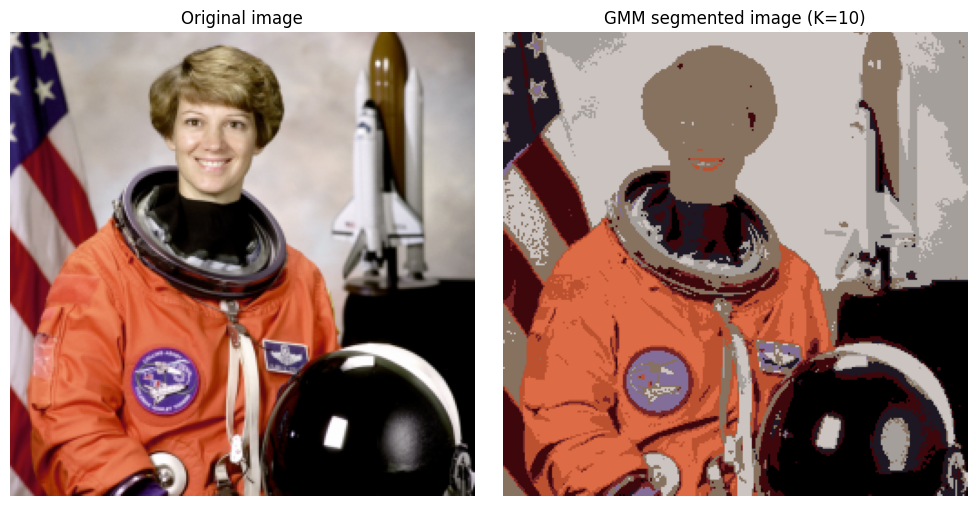

In [12]:
# Step 4: Reconstruct image by replacing each pixel with its cluster's mean color
cluster_labels = gmm_img.predict(pixels)           # (N,) cluster index for each pixel
cluster_means  = gmm_img.means_.astype('uint8')    # (K, 3) mean RGB per cluster

reconstructed_pixels = cluster_means[cluster_labels]          # (N, 3)
reconstructed_image  = reconstructed_pixels.reshape(h, w, c)  # (h, w, 3)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].axis('off')
axes[0].set_title('Original image')

axes[1].imshow(reconstructed_image)
axes[1].axis('off')
axes[1].set_title('GMM segmented image (K=10)')

plt.tight_layout()
plt.show()


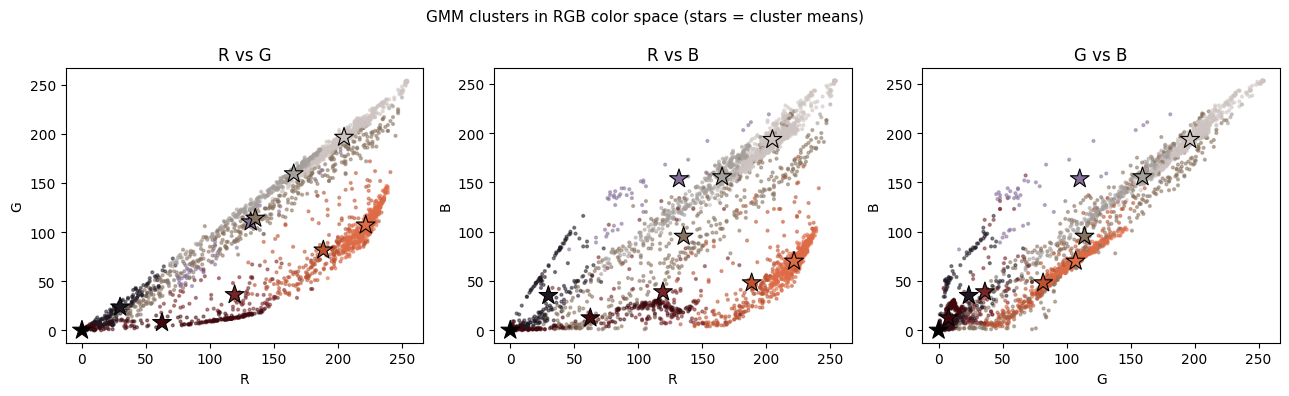

In [13]:
# Visualize clusters in RGB feature space (3 pairwise projections)
# Sample a subset of pixels so the plot isn't too slow
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(pixels), size=3000, replace=False)
px_sample   = pixels[sample_idx]
lbl_sample  = cluster_labels[sample_idx]

# Use each cluster's mean color (normalized to [0,1]) as the point color
palette = gmm_img.means_ / 255.0  # (K, 3)
point_colors = palette[lbl_sample]

pairs   = [(0, 1, 'R', 'G'), (0, 2, 'R', 'B'), (1, 2, 'G', 'B')]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (xi, yi, xlabel, ylabel) in zip(axes, pairs):
    ax.scatter(px_sample[:, xi], px_sample[:, yi],
               c=point_colors, s=4, alpha=0.5)
    # Overlay cluster means as black-outlined stars
    ax.scatter(gmm_img.means_[:, xi], gmm_img.means_[:, yi],
               c=palette, s=200, marker='*',
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{xlabel} vs {ylabel}')

plt.suptitle('GMM clusters in RGB color space (stars = cluster means)', fontsize=11)
plt.tight_layout()
plt.show()


**Answer to 5:**  Since K-means uses only Euclidean distance, it can't capture a tilted/elongated shape whereas a GMM fits a full covaraince matrix which can be tilted/elongated along any direction. This allows GMM to fit this tilt in feature space as visualized above. 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.14/lib/p

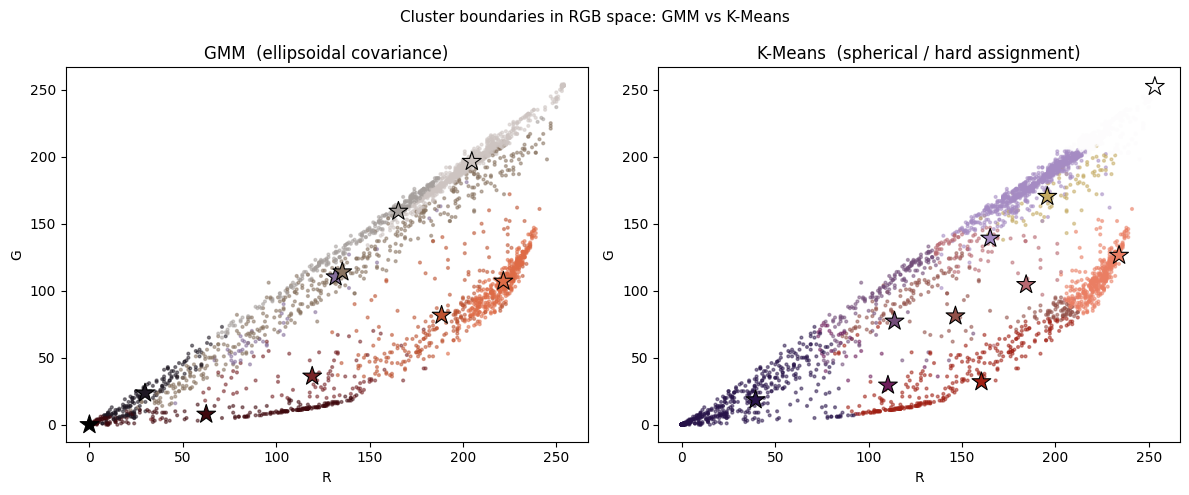

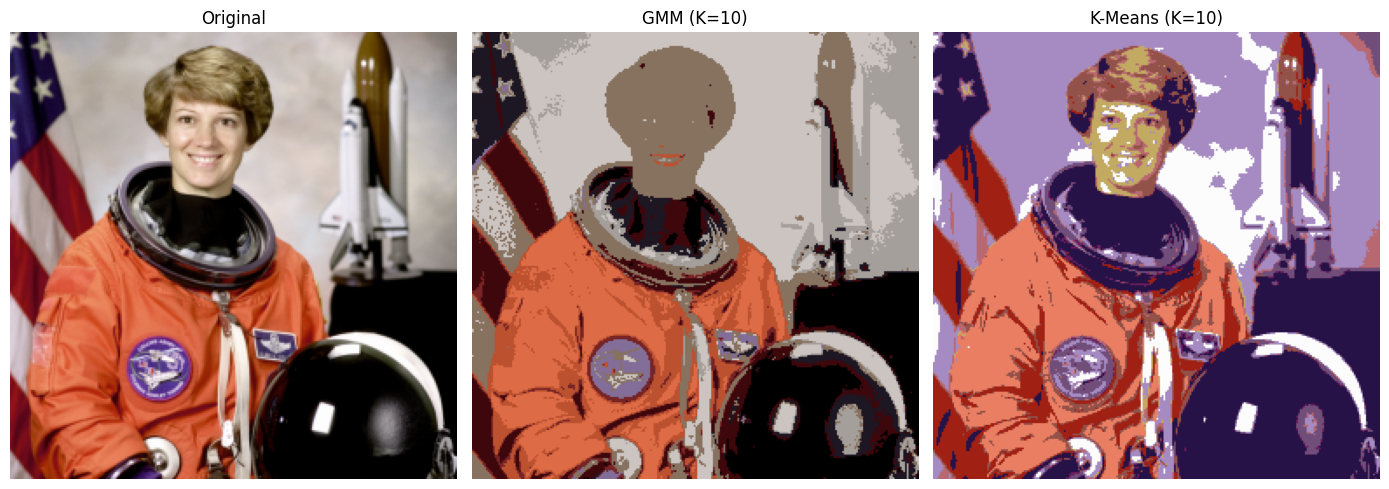

In [14]:
from sklearn.cluster import KMeans

# Fit K-Means with K=10 to the same pixel data
km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(pixels)

km_labels  = km.labels_[sample_idx]
km_palette = km.cluster_centers_ / 255.0          # (K, 3) normalized for color
km_colors  = km_palette[km_labels]

# Side-by-side: GMM vs K-Means in R vs G space
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (lbl, pal, title) in zip(axes, [
    (lbl_sample,  palette,    'GMM  (ellipsoidal covariance)'),
    (km_labels,   km_palette, 'K-Means  (spherical / hard assignment)'),
]):
    pt_col = pal[lbl]
    ax.scatter(px_sample[:, 0], px_sample[:, 1], c=pt_col, s=4, alpha=0.5)
    ax.scatter(pal[:, 0] * 255, pal[:, 1] * 255,
               c=pal, s=200, marker='*', edgecolors='black', linewidths=0.8, zorder=5)
    ax.set_xlabel('R')
    ax.set_ylabel('G')
    ax.set_title(title)

plt.suptitle('Cluster boundaries in RGB space: GMM vs K-Means', fontsize=11)
plt.tight_layout()
plt.show()

# Also show the reconstructed image side-by-side
km_recon = km.cluster_centers_.astype('uint8')[km.labels_].reshape(h, w, c)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(image);          axes[0].axis('off'); axes[0].set_title('Original')
axes[1].imshow(reconstructed_image); axes[1].axis('off'); axes[1].set_title('GMM (K=10)')
axes[2].imshow(km_recon);       axes[2].axis('off'); axes[2].set_title('K-Means (K=10)')
plt.tight_layout()
plt.show()


We can see that K-means does not replicate the original image colors very well and produces more contrast in the image 